# 대학생 중도이탈 예측 — 전처리 + EDA

이 노트북은 기존 `preprocessing_Eunha.ipynb`의 전처리 로직을 유지하고,  
전처리 완료 데이터 `df_kr`를 기준으로 **탐색적 데이터 분석(EDA)** 을 추가한 버전입니다.

### 분석 흐름
1. 원본 데이터 로드 및 한국 적용형 전처리
2. 데이터 품질 점검
3. Target(중도이탈) 분포 확인
4. 경제·개인 특성별 중도이탈률 분석
5. 학업성과와 중도이탈 관계 분석
6. 파생변수 검토
7. 상관관계 분석
8. 모델링 전 핵심 인사이트 정리

> **Target_binary 정의**  
> `1 = Dropout`, `0 = Graduate + Enrolled`  
> 따라서 그래프나 표에서 **중도이탈률이 높을수록 위험도가 높다**고 해석합니다.


## 0. 전처리

아래 셀은 기존 전처리 코드의 핵심 로직을 그대로 사용합니다.  
다만 데이터 파일은 GitHub 프로젝트 구조를 고려해 `data/raw/data.csv` 등을 자동으로 찾도록 수정했습니다.


In [2]:
import pandas as pd
import numpy as np

# ============================================================
# 0. 데이터 불러오기
# ============================================================
# UCI 원본 csv가 ; 구분자인 경우
from pathlib import Path

# 프로젝트에서 흔히 사용하는 위치를 순서대로 탐색
data_candidates = [
    Path("data/raw/data.csv"),       # 프로젝트 루트에서 실행
    Path("../data/raw/data.csv"),    # notebooks/에서 실행
    Path("data.csv"),                # 기존 코드 호환
    Path("data(1).csv"),             # 업로드 파일명 호환
    Path("../data(1).csv"),
]

data_path = next((p for p in data_candidates if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "데이터 파일을 찾을 수 없습니다. "
        "권장 위치: 프로젝트의 data/raw/data.csv"
    )

print("사용 데이터:", data_path.resolve())
df = pd.read_csv(data_path, sep=";")

# 원본 보존
df_kr = df.copy()

print("원본 shape:", df_kr.shape)


# ============================================================
# 1. Target → 이진분류
# ============================================================
# 1 = Dropout
# 0 = Graduate + Enrolled

df_kr["Target_binary"] = df_kr["Target"].map({
    "Dropout": 1,
    "Graduate": 0,
    "Enrolled": 0
})

# 기존 3-class Target 제거
df_kr.drop(columns=["Target"], inplace=True)

print("\n[Target 분포]")
print(df_kr["Target_binary"].value_counts())

print("\n[Target 비율]")
print(
    df_kr["Target_binary"]
    .value_counts(normalize=True)
    .round(3)
)


# ============================================================
# 2. Application mode
#    포르투갈 입학전형 → 국가 중립적인 입학경로
# ============================================================

application_mode_map = {

    # 일반 입학
    1: "General",
    17: "General",
    18: "General",

    # 지역/특별 전형
    5: "Special",
    16: "Special",

    # 외국인
    15: "International",

    # 성인 학습자
    39: "Adult_Learner",

    # 편입 / 과정 변경
    42: "Transfer_Change",
    43: "Transfer_Change",
    51: "Transfer_Change",
    57: "Transfer_Change",

    # 기존 고등교육 경험/학위
    7: "Previous_HE",

    # 직업·기술교육
    44: "Vocational",
    53: "Vocational",

    # 포르투갈 고유 법령 등에 따른 전형
    2: "Other_Special",
    10: "Other_Special",
    26: "Other_Special",
    27: "Other_Special"
}

df_kr["Admission_pathway"] = (
    df_kr["Application mode"]
    .map(application_mode_map)
    .fillna("Other")
)

# 원래 포르투갈 Application mode 제거
df_kr.drop(columns=["Application mode"], inplace=True)


# ============================================================
# 3. Course
#    개별 학과 → 일반화된 전공 계열
# ============================================================
# UCI 데이터의 Course code 기준
#
# ⚠️ 아래 grouping은 '한국 공식 학과 분류'가 아니라
# 프로젝트에서 국가 종속성을 낮추기 위한 분석용 재분류입니다.

course_map = {

    # 농생명 / 자연
    33: "Agriculture_Natural",
    9130: "Agriculture_Natural",
    9085: "Agriculture_Natural",

    # 디자인 / 예술
    171: "Arts_Design",
    9070: "Arts_Design",

    # 사회 / 교육
    8014: "Social_Education",
    9238: "Social_Education",
    9773: "Social_Education",
    9853: "Social_Education",

    # 경영 / 관광
    9003: "Business_Service",
    9254: "Business_Service",
    9500: "Business_Service",

    # 보건
    9119: "Health",
    9556: "Health",
    9670: "Health",

    # 공학 / IT
    9991: "Engineering_IT"
}

df_kr["Course_group"] = (
    df_kr["Course"]
    .map(course_map)
    .fillna("Other")
)

df_kr.drop(columns=["Course"], inplace=True)


# ============================================================
# 4. Previous qualification
#    포르투갈 교육제도 → 일반적인 이전 학력
# ============================================================
#
# 여기서는 너무 세밀하게 구분하기보다
# 국가 간 비교가 가능한 상위 개념으로 단순화합니다.

previous_qualification_map = {

    # Secondary education
    1: "Secondary",

    # Higher education
    2: "Higher_Education",
    3: "Higher_Education",
    4: "Higher_Education",
    5: "Higher_Education",
    6: "Higher_Education",

    # Secondary 수준 교육과정
    9: "Secondary",
    10: "Secondary",
    12: "Secondary",
    14: "Secondary",
    15: "Secondary",

    # Basic education
    19: "Below_Secondary",
    38: "Below_Secondary",

    # Vocational / technological
    39: "Vocational",
    40: "Vocational",
    42: "Vocational",
    43: "Vocational"
}

df_kr["Previous_qualification_group"] = (
    df_kr["Previous qualification"]
    .map(previous_qualification_map)
    .fillna("Other")
)

df_kr.drop(columns=["Previous qualification"], inplace=True)


# ============================================================
# 5. 부모 학력
#    세부 교육과정 → 학력 수준
# ============================================================
#
# 부모 학력 코드는 종류가 많기 때문에
# 프로젝트 초기 단계에서는 보수적으로 묶습니다.

def group_parent_qualification(x):

    # 대학/고등교육 계열
    higher = [
        2, 3, 4, 5, 6, 40, 41, 42, 43, 44
    ]

    # 중등교육
    secondary = [
        1, 9, 10, 11, 12, 13, 14
    ]

    # 기초교육
    basic = [
        19, 20, 22, 25, 26, 27, 29, 30
    ]

    if x in higher:
        return "Higher_Education"

    elif x in secondary:
        return "Secondary"

    elif x in basic:
        return "Basic"

    else:
        return "Other"


df_kr["Mother_education_group"] = (
    df_kr["Mother's qualification"]
    .apply(group_parent_qualification)
)

df_kr["Father_education_group"] = (
    df_kr["Father's qualification"]
    .apply(group_parent_qualification)
)

df_kr.drop(
    columns=[
        "Mother's qualification",
        "Father's qualification"
    ],
    inplace=True
)


# ============================================================
# 6. 부모 직업
#    포르투갈 세부 직업코드 → 광범위한 직업군
# ============================================================
#
# 직업 코드는 한국 직업분류와 직접 대응시키기 어렵기 때문에
# 너무 세세하게 해석하지 않는 것이 좋습니다.

def group_occupation(x):

    # 관리자 / 전문직
    if x in [1, 2, 3]:
        return "Professional_Managerial"

    # 사무 / 서비스 / 판매
    elif x in [4, 5]:
        return "Clerical_Service"

    # 농림
    elif x == 6:
        return "Agriculture"

    # 기술 / 생산
    elif x in [7, 8]:
        return "Technical_Production"

    # 단순노무
    elif x == 9:
        return "Elementary"

    # 학생 / 무직 / 기타
    else:
        return "Other"


df_kr["Mother_occupation_group"] = (
    df_kr["Mother's occupation"]
    .apply(group_occupation)
)

df_kr["Father_occupation_group"] = (
    df_kr["Father's occupation"]
    .apply(group_occupation)
)

df_kr.drop(
    columns=[
        "Mother's occupation",
        "Father's occupation"
    ],
    inplace=True
)


# ============================================================
# 7. Nacionality 제거
# ============================================================
#
# 원본에는 이미 International 변수가 존재합니다.
# 따라서 한국형 모델에서는 세부 국적을 제거하고
# International만 사용합니다.

df_kr.drop(columns=["Nacionality"], inplace=True)


# ============================================================
# 8. 포르투갈 거시경제 변수 제거
# ============================================================
#
# 포르투갈 특정 시점의 경제 상황이므로
# 한국 적용형 모델에서는 제외합니다.

macro_columns = [
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

df_kr.drop(columns=macro_columns, inplace=True)


# ============================================================
# 9. 파생변수 생성
# ============================================================
# 0으로 나누는 문제를 방지하기 위해
# enrolled가 0이면 NaN → 이후 0 처리

# ----------------------------
# 1학기 이수율
# ----------------------------
df_kr["Sem1_approval_rate"] = np.where(
    df_kr["Curricular units 1st sem (enrolled)"] > 0,

    df_kr["Curricular units 1st sem (approved)"]
    / df_kr["Curricular units 1st sem (enrolled)"],

    0
)


# ----------------------------
# 2학기 이수율
# ----------------------------
df_kr["Sem2_approval_rate"] = np.where(
    df_kr["Curricular units 2nd sem (enrolled)"] > 0,

    df_kr["Curricular units 2nd sem (approved)"]
    / df_kr["Curricular units 2nd sem (enrolled)"],

    0
)


# ----------------------------
# 미평가 비율
# ----------------------------
df_kr["Sem1_no_eval_rate"] = np.where(
    df_kr["Curricular units 1st sem (enrolled)"] > 0,

    df_kr["Curricular units 1st sem (without evaluations)"]
    / df_kr["Curricular units 1st sem (enrolled)"],

    0
)

df_kr["Sem2_no_eval_rate"] = np.where(
    df_kr["Curricular units 2nd sem (enrolled)"] > 0,

    df_kr["Curricular units 2nd sem (without evaluations)"]
    / df_kr["Curricular units 2nd sem (enrolled)"],

    0
)


# ----------------------------
# 성적 변화
# 2학기 - 1학기
# ----------------------------
df_kr["Grade_change"] = (
    df_kr["Curricular units 2nd sem (grade)"]
    - df_kr["Curricular units 1st sem (grade)"]
)


# ----------------------------
# 이수율 변화
# ----------------------------
df_kr["Approval_rate_change"] = (
    df_kr["Sem2_approval_rate"]
    - df_kr["Sem1_approval_rate"]
)


# ============================================================
# 10. 결과 확인
# ============================================================

print("\n==============================")
print("한국 적용형 데이터")
print("==============================")

print("shape:", df_kr.shape)

print("\n컬럼:")
for col in df_kr.columns:
    print("-", col)

print("\n결측치:")
print(df_kr.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget:")
print(df_kr["Target_binary"].value_counts())

사용 데이터: C:\SKN-35-S2\SKN35-2nd-1Team\data\raw\data.csv
원본 shape: (4424, 37)

[Target 분포]
Target_binary
0    3003
1    1421
Name: count, dtype: int64

[Target 비율]
Target_binary
0    0.679
1    0.321
Name: proportion, dtype: float64

한국 적용형 데이터
shape: (4424, 39)

컬럼:
- Marital status
- Application order
- Daytime/evening attendance	
- Previous qualification (grade)
- Admission grade
- Displaced
- Educational special needs
- Debtor
- Tuition fees up to date
- Gender
- Scholarship holder
- Age at enrollment
- International
- Curricular units 1st sem (credited)
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 1st sem (without evaluations)
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluation

# 11. EDA 시작

EDA의 목적은 단순히 그래프를 많이 그리는 것이 아니라,  
**"어떤 학생 특성이 중도이탈과 관련되어 보이는가?"** 를 확인하여 모델링과 대응방안 설계의 근거를 만드는 것입니다.


## 11-1. 데이터 구조 · 결측치 · 중복 확인

In [3]:
# 데이터 구조 확인
print("데이터 크기:", df_kr.shape)
print("\n데이터 타입:")
display(df_kr.dtypes.value_counts().rename("count").to_frame())

# 결측치 확인
missing = (
    df_kr.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_rate=lambda x: x["missing_count"] / len(df_kr))
    .sort_values("missing_count", ascending=False)
)

print("\n결측치가 있는 컬럼 수:", (missing["missing_count"] > 0).sum())
display(missing.head(15))

# 중복 행 확인
duplicate_count = df_kr.duplicated().sum()
print("\n중복 행 수:", duplicate_count)


데이터 크기: (4424, 39)

데이터 타입:


,count
int64,22
float64,10
str,7



결측치가 있는 컬럼 수: 0


,missing_count,missing_rate
Marital status,0,0.0
Application order,0,0.0
Daytime/evening attendance\t,0,0.0
Previous qualification (grade),0,0.0
Admission grade,0,0.0
Displaced,0,0.0
Educational special needs,0,0.0
Debtor,0,0.0
Tuition fees up to date,0,0.0
Gender,0,0.0



중복 행 수: 0


### 확인 포인트
- 결측치가 있다면 모델 학습 전에 처리 방법을 결정해야 합니다.
- 중복 행이 있다면 실제 중복인지, 서로 다른 학생이 우연히 동일한 특성을 가진 것인지 확인이 필요합니다.
- 이 데이터는 전처리 후 **4,424개 관측치**를 유지하는지 확인합니다.


## 11-2. Target 분포 — 중도이탈 비율

,count,rate
Non-dropout (0),3003,67.9%
Dropout (1),1421,32.1%


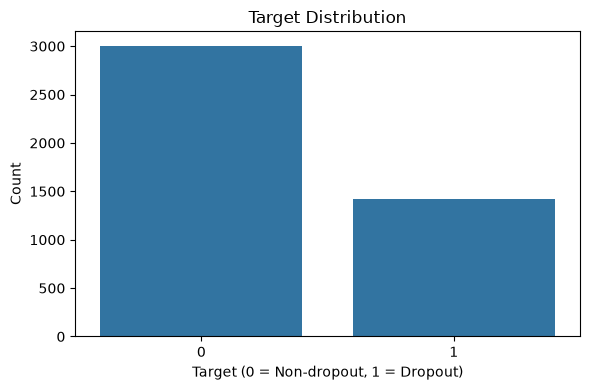

전체 중도이탈률: 32.1%


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

target_summary = pd.DataFrame({
    "count": df_kr["Target_binary"].value_counts().sort_index(),
    "rate": df_kr["Target_binary"].value_counts(normalize=True).sort_index()
})
target_summary.index = ["Non-dropout (0)", "Dropout (1)"]

display(target_summary.style.format({"rate": "{:.1%}"}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_kr, x="Target_binary")
plt.title("Target Distribution")
plt.xlabel("Target (0 = Non-dropout, 1 = Dropout)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"전체 중도이탈률: {df_kr['Target_binary'].mean():.1%}")


### 실제 데이터 해석
업로드된 데이터 기준으로 원래 Target은 `Graduate 2,209명`, `Enrolled 794명`, `Dropout 1,421명`입니다.  
이진화 후 중도이탈은 약 **32.1%**, 비중도이탈은 약 **67.9%**입니다.

즉 완전히 극단적인 불균형은 아니지만, 모델 평가에서 단순 Accuracy만 보기보다  
**Recall, F1-score, ROC-AUC, PR-AUC** 등을 함께 보는 것이 좋습니다.


## 11-3. 핵심 개인·경제 변수별 중도이탈률

In [5]:
binary_features = [
    "Tuition fees up to date",
    "Debtor",
    "Scholarship holder",
    "Gender",
    "International",
    "Displaced",
    "Educational special needs",
]

def dropout_rate_table(data, column):
    result = (
        data.groupby(column, observed=False)["Target_binary"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "dropout_rate"})
        .sort_values("dropout_rate", ascending=False)
    )
    return result

for col in binary_features:
    print(f"\n===== {col} =====")
    display(
        dropout_rate_table(df_kr, col)
        .style.format({"dropout_rate": "{:.1%}"})
    )



===== Tuition fees up to date =====


,count,dropout_rate
Tuition fees up to date,,
0,528,86.6%
1,3896,24.7%



===== Debtor =====


,count,dropout_rate
Debtor,,
1,503,62.0%
0,3921,28.3%



===== Scholarship holder =====


...

,count,dropout_rate
International,,
0,4314,32.2%
1,110,29.1%



===== Displaced =====


,count,dropout_rate
Displaced,,
0,1998,37.6%
1,2426,27.6%



===== Educational special needs =====


,count,dropout_rate
Educational special needs,,
1,51,33.3%
0,4373,32.1%


### 핵심 확인 포인트
특히 아래 변수는 중도이탈률 차이가 큰지 확인합니다.

- `Tuition fees up to date`: 등록금 납부 상태
- `Debtor`: 채무 여부
- `Scholarship holder`: 장학금 수혜 여부

이 변수들은 단순 예측 변수에 그치지 않고,  
**대학이 실제로 개입할 수 있는 정책·지원 방안**과 연결될 가능성이 높다는 점에서 중요합니다.


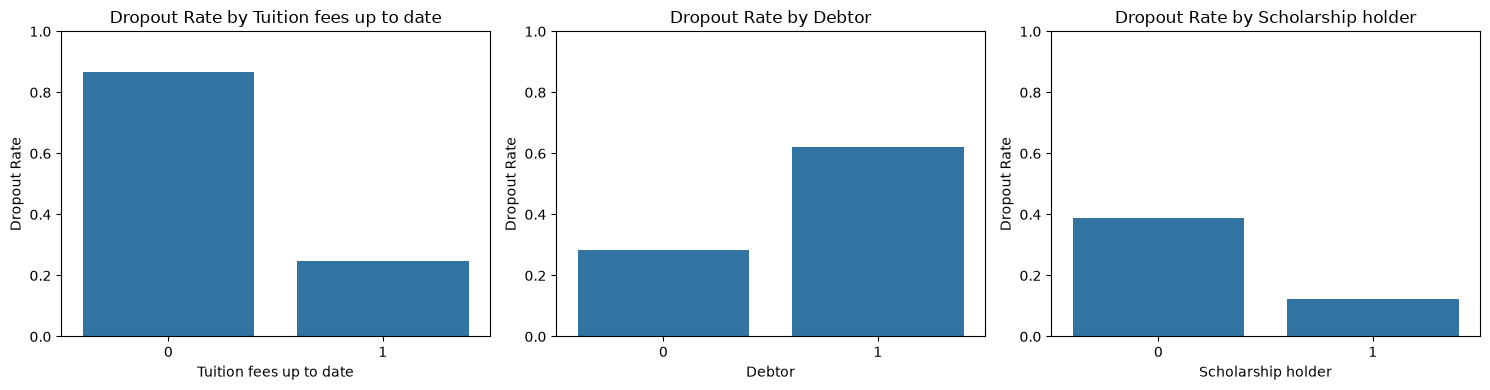

In [6]:
# 핵심 경제 변수 시각화
economic_features = [
    "Tuition fees up to date",
    "Debtor",
    "Scholarship holder",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, economic_features):
    rate = (
        df_kr.groupby(col)["Target_binary"]
        .mean()
        .reset_index()
    )
    sns.barplot(data=rate, x=col, y="Target_binary", ax=ax)
    ax.set_title(f"Dropout Rate by {col}")
    ax.set_ylabel("Dropout Rate")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


### 업로드 데이터에서 보이는 대표 패턴
실제 데이터 기준으로:

- **등록금 미납(0)** 학생의 중도이탈률은 약 **86.6%**
- 등록금 정상 납부(1) 학생은 약 **24.7%**
- **채무 있음(1)** 학생은 약 **62.0%**
- 채무 없음(0)은 약 **28.3%**
- **장학금 수혜(1)** 학생은 약 **12.2%**
- 장학금 미수혜(0)는 약 **38.7%**

따라서 재정 상태 관련 변수가 중도이탈과 상당한 연관을 보입니다.  
다만 이는 **상관관계**이며, 이 변수 하나가 중도이탈의 원인이라고 단정하면 안 됩니다.


## 11-4. 범주형 변수별 중도이탈률


===== Admission_pathway =====


,count,dropout_rate
Admission_pathway,,
Previous_HE,139,61.2%
Adult_Learner,785,55.4%
Other_Special,15,46.7%
Transfer_Change,449,37.6%
Vocational,248,27.0%
General,2704,23.9%
International,30,16.7%
Special,54,13.0%


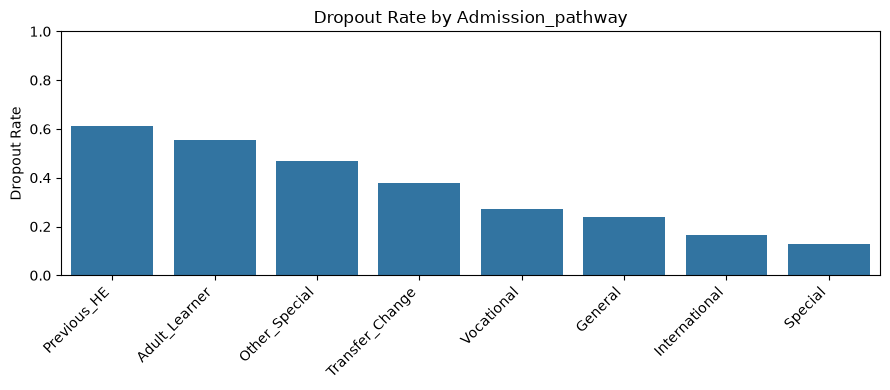


===== Course_group =====


,count,dropout_rate
Course_group,,
Engineering_IT,268,50.7%
Health,524,42.0%
Agriculture_Natural,490,35.9%
Other,380,35.3%
Arts_Design,441,30.2%
Social_Education,1093,29.5%
Business_Service,1228,24.4%


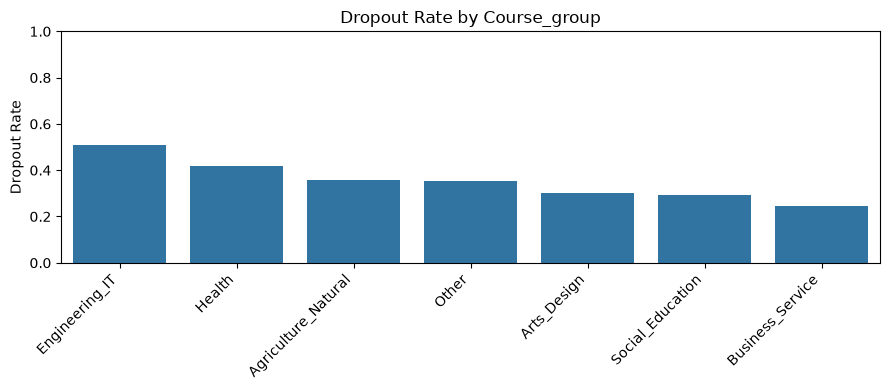


===== Previous_qualification_group =====


,count,dropout_rate
Previous_qualification_group,,
Below_Secondary,169,63.3%
Higher_Education,174,59.2%
Vocational,301,30.2%
Secondary,3780,29.6%


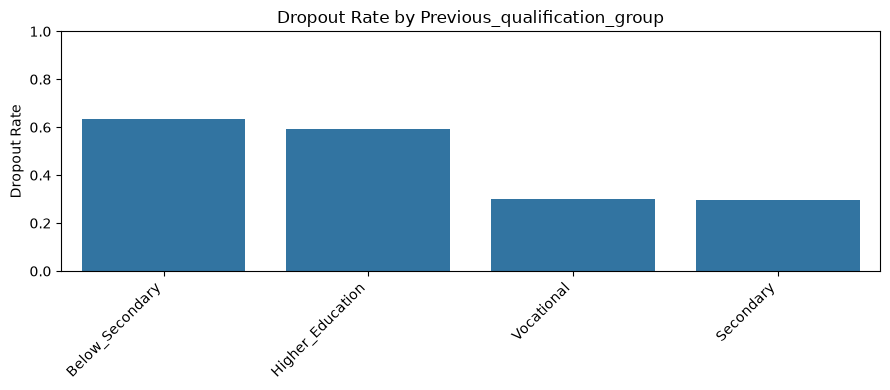


===== Mother_education_group =====


,count,dropout_rate
Mother_education_group,,
Other,1716,36.6%
Higher_Education,619,30.2%
Secondary,1127,29.5%
Basic,962,28.5%


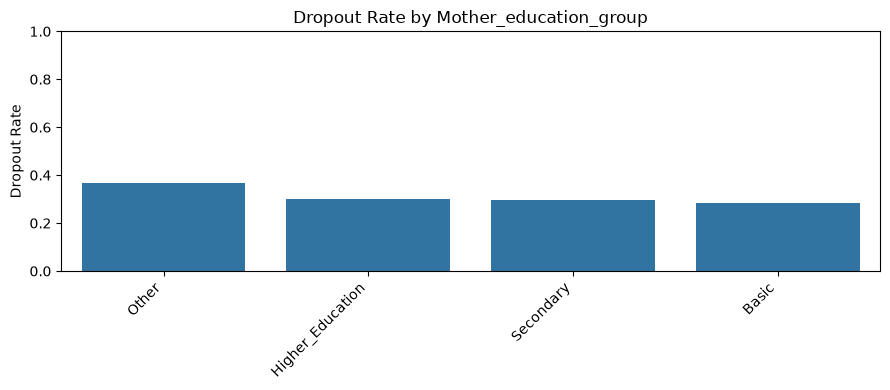


===== Father_education_group =====


,count,dropout_rate
Father_education_group,,
Higher_Education,420,34.0%
Other,2056,33.9%
Secondary,964,31.5%
Basic,984,28.0%


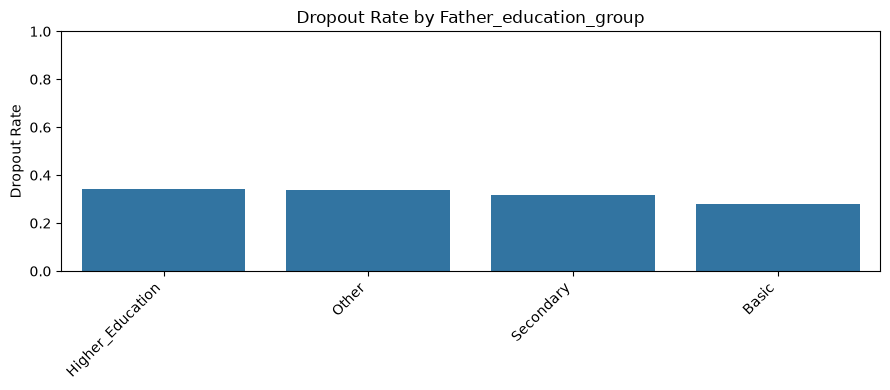


===== Mother_occupation_group =====


,count,dropout_rate
Mother_occupation_group,,
Other,330,51.5%
Elementary,1577,31.1%
Technical_Production,308,30.8%
Professional_Managerial,771,30.6%
Clerical_Service,1347,30.0%
Agriculture,91,28.6%


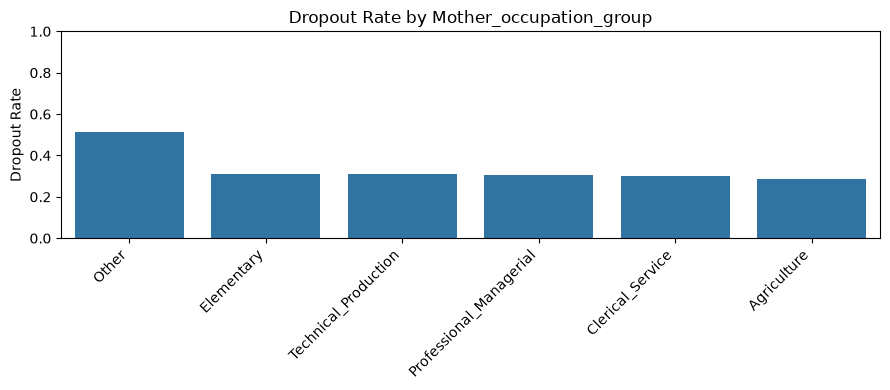


===== Father_occupation_group =====


,count,dropout_rate
Father_occupation_group,,
Other,571,40.6%
Professional_Managerial,715,32.4%
Elementary,1010,32.0%
Clerical_Service,902,31.8%
Agriculture,242,28.5%
Technical_Production,984,28.3%


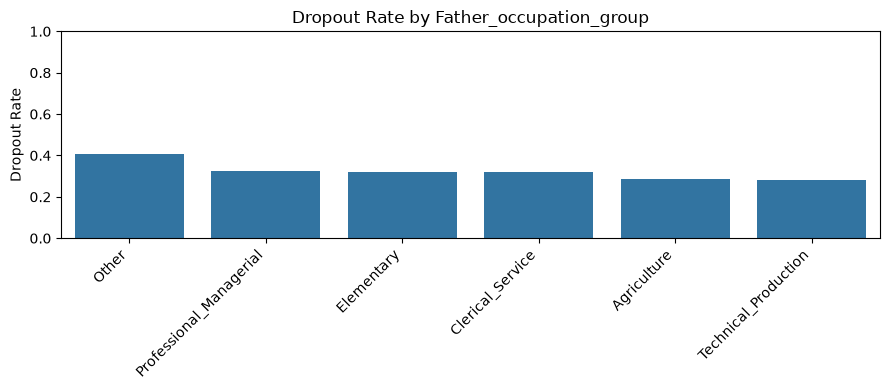

In [7]:
categorical_features = [
    "Admission_pathway",
    "Course_group",
    "Previous_qualification_group",
    "Mother_education_group",
    "Father_education_group",
    "Mother_occupation_group",
    "Father_occupation_group",
]

for col in categorical_features:
    rate = (
        df_kr.groupby(col, observed=False)["Target_binary"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "dropout_rate"})
        .sort_values("dropout_rate", ascending=False)
    )

    print(f"\n===== {col} =====")
    display(rate.style.format({"dropout_rate": "{:.1%}"}))

    plt.figure(figsize=(9, 4))
    plot_data = rate.reset_index()
    sns.barplot(data=plot_data, x=col, y="dropout_rate")
    plt.title(f"Dropout Rate by {col}")
    plt.ylabel("Dropout Rate")
    plt.xlabel("")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


### 해석 시 주의
범주별 중도이탈률이 높아도 **표본 수(count)가 매우 작다면** 우연에 의한 차이일 수 있습니다.  
따라서 반드시 `dropout_rate`와 `count`를 함께 확인합니다.

또한 `Course_group`, `Admission_pathway` 등은 프로젝트에서 국가 종속성을 낮추기 위해 재분류한 변수이므로,  
이를 **한국의 공식 학과/입학전형 분류라고 해석하면 안 됩니다.**


## 11-5. 연령과 입학 성적

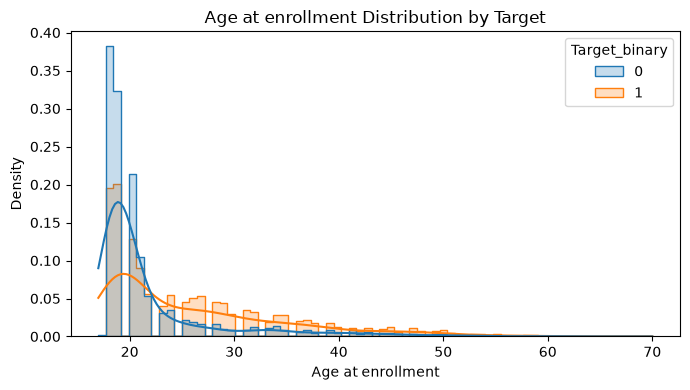

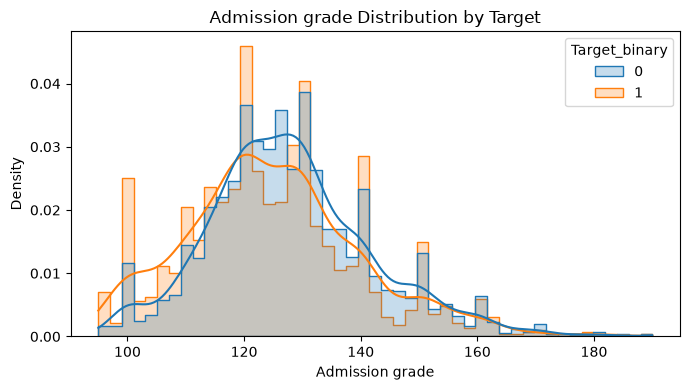

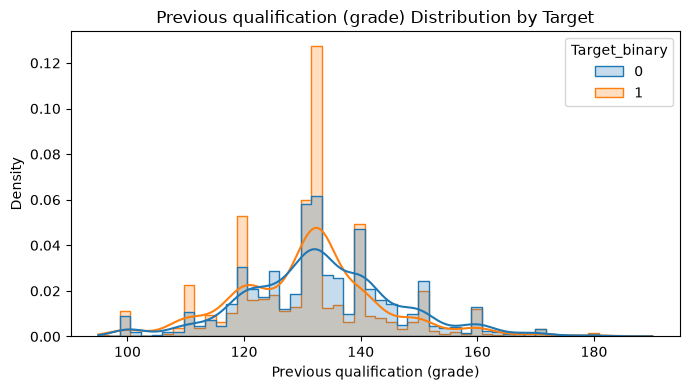

Age at enrollment        Admission grade         \
                           mean median            mean median   
Target_binary                                                   
0                         21.94   19.0          127.93  126.7   
1                         26.07   23.0          124.96  123.6   

              Previous qualification (grade)         
                                        mean median  
Target_binary                                        
0                                     133.32  133.1  
1                                     131.11  133.1

In [8]:
numeric_basic = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
]

for col in numeric_basic:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df_kr,
        x=col,
        hue="Target_binary",
        kde=True,
        stat="density",
        common_norm=False,
        element="step"
    )
    plt.title(f"{col} Distribution by Target")
    plt.tight_layout()
    plt.show()

display(
    df_kr.groupby("Target_binary")[numeric_basic]
    .agg(["mean", "median"])
    .round(2)
)


### 확인 포인트
- 중도이탈 집단의 입학 연령이 상대적으로 높은가?
- 입학 성적이나 이전 학력 성적에서 두 집단의 차이가 있는가?
- 분포가 심하게 겹친다면 해당 변수 하나만으로 학생을 구분하기는 어렵습니다.


## 11-6. 학업성과와 중도이탈 ⭐

In [9]:
academic_features = [
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Sem1_approval_rate",
    "Sem2_approval_rate",
    "Sem1_no_eval_rate",
    "Sem2_no_eval_rate",
    "Grade_change",
    "Approval_rate_change",
]

academic_summary = (
    df_kr.groupby("Target_binary")[academic_features]
    .mean()
    .T
    .rename(columns={0: "Non-dropout_mean", 1: "Dropout_mean"})
)

academic_summary["difference_dropout_minus_non"] = (
    academic_summary["Dropout_mean"]
    - academic_summary["Non-dropout_mean"]
)

display(academic_summary.round(3))


Target_binary,Non-dropout_mean,Dropout_mean,difference_dropout_minus_non
Curricular units 1st sem (grade),12.242,7.257,-4.986
Curricular units 2nd sem (grade),12.280,5.899,-6.380
Sem1_approval_rate,0.846,0.384,-0.462
Sem2_approval_rate,0.834,0.293,-0.541
Sem1_no_eval_rate,0.016,0.034,0.018
Sem2_no_eval_rate,0.017,0.041,0.024
Grade_change,0.037,-1.357,-1.395
Approval_rate_change,-0.012,-0.091,-0.078


### 실제 데이터에서 확인되는 학업 패턴
업로드된 데이터의 평균을 비교하면:

| 변수 | 비중도이탈 평균 | 중도이탈 평균 |
|---|---:|---:|
| 1학기 이수율 | 약 0.846 | 약 0.384 |
| 2학기 이수율 | 약 0.834 | 약 0.293 |
| 1학기 평균성적 | 약 12.24 | 약 7.26 |
| 2학기 평균성적 | 약 12.28 | 약 5.90 |
| 성적 변화(2학기-1학기) | 약 +0.04 | 약 -1.36 |
| 이수율 변화(2학기-1학기) | 약 -0.01 | 약 -0.09 |

중도이탈 집단에서는 특히 **2학기 이수율과 성적이 더 낮게 나타나는 패턴**이 보입니다.  
이는 네가 만든 `Sem1/2_approval_rate`, `Grade_change`, `Approval_rate_change`가  
학생의 학업 악화를 표현하는 데 유용할 가능성을 보여줍니다.


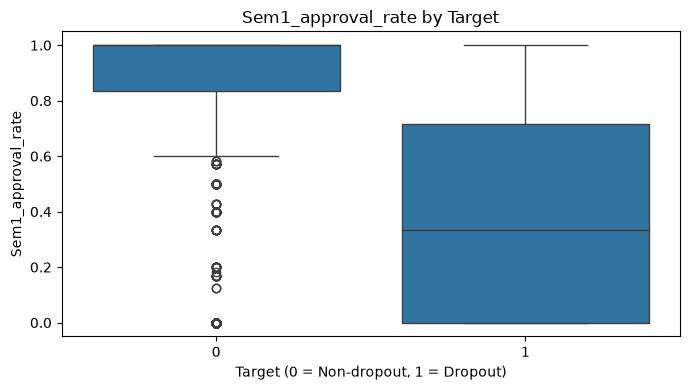

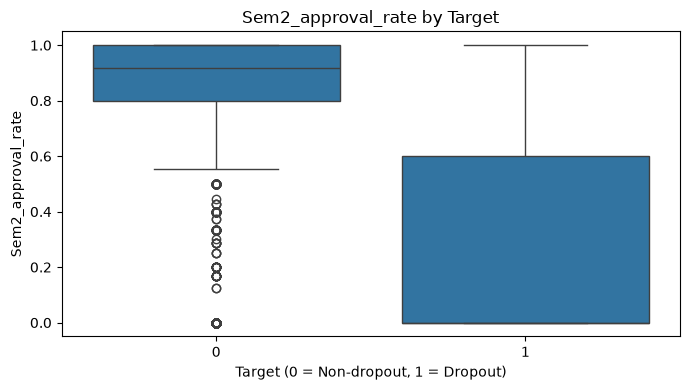

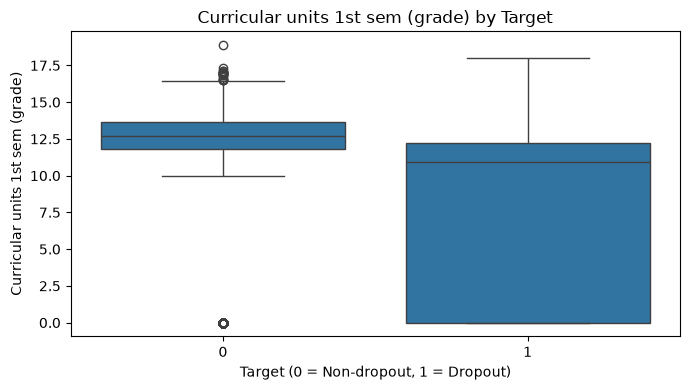

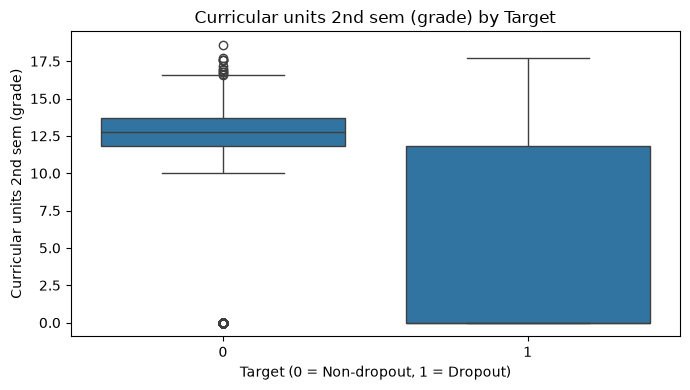

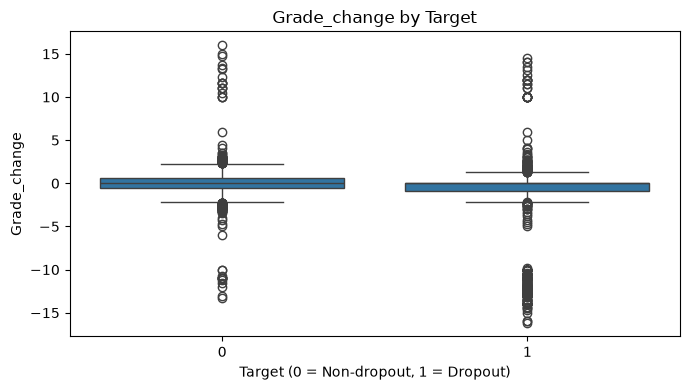

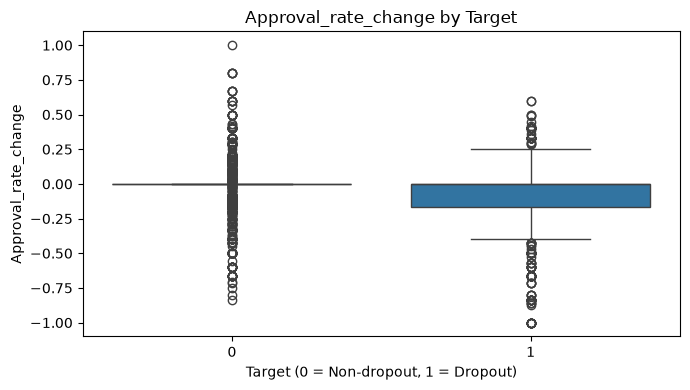

In [10]:
# 핵심 학업 변수 분포 비교
plot_academic = [
    "Sem1_approval_rate",
    "Sem2_approval_rate",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Grade_change",
    "Approval_rate_change",
]

for col in plot_academic:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_kr, x="Target_binary", y=col)
    plt.title(f"{col} by Target")
    plt.xlabel("Target (0 = Non-dropout, 1 = Dropout)")
    plt.tight_layout()
    plt.show()


## 11-7. 1학기 → 2학기 변화 확인

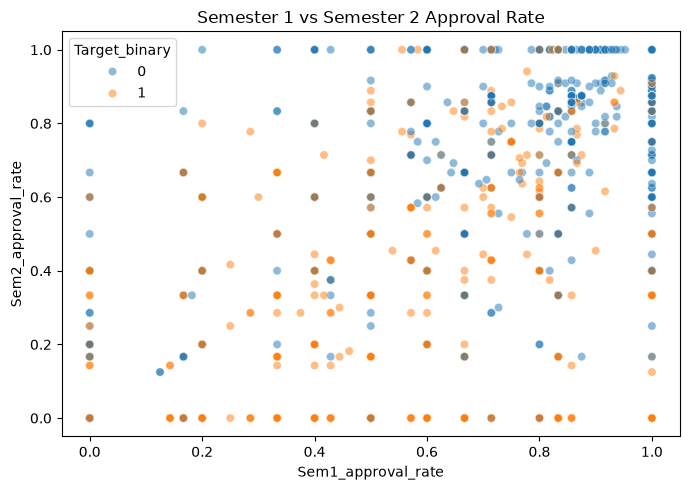

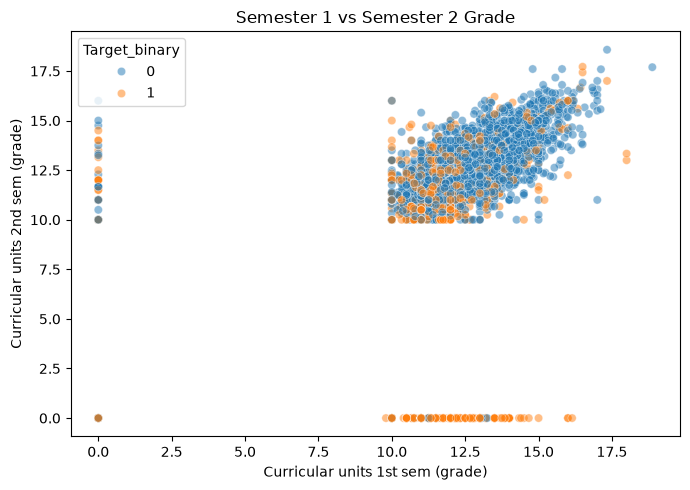

In [11]:
# 이수율 변화
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_kr,
    x="Sem1_approval_rate",
    y="Sem2_approval_rate",
    hue="Target_binary",
    alpha=0.5
)
plt.title("Semester 1 vs Semester 2 Approval Rate")
plt.tight_layout()
plt.show()

# 성적 변화
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_kr,
    x="Curricular units 1st sem (grade)",
    y="Curricular units 2nd sem (grade)",
    hue="Target_binary",
    alpha=0.5
)
plt.title("Semester 1 vs Semester 2 Grade")
plt.tight_layout()
plt.show()


### 왜 이 분석이 중요한가?
단순히 '성적이 낮다'보다 **1학기에서 2학기로 갈수록 성적·이수율이 악화되는 학생**을 조기에 탐지할 수 있다면,  
중도이탈 예방 정책과 직접 연결하기 쉽습니다.

예:
- 학업 상담
- 튜터링/보충학습
- 등록금 및 장학 지원 안내
- 위험학생 조기경보(Early Warning System)


## 11-8. 수치형 변수 상관관계

Target_binary와 절대 상관계수가 큰 변수 Top 15


,correlation
Sem2_approval_rate,-0.659413
Sem1_approval_rate,-0.591236
Curricular units 2nd sem (grade),-0.571792
Curricular units 2nd sem (approved),-0.569500
Curricular units 1st sem (grade),-0.480669
Curricular units 1st sem (approved),-0.479112
Tuition fees up to date,-0.429149
Age at enrollment,0.254215
Scholarship holder,-0.245354
Debtor,0.229407


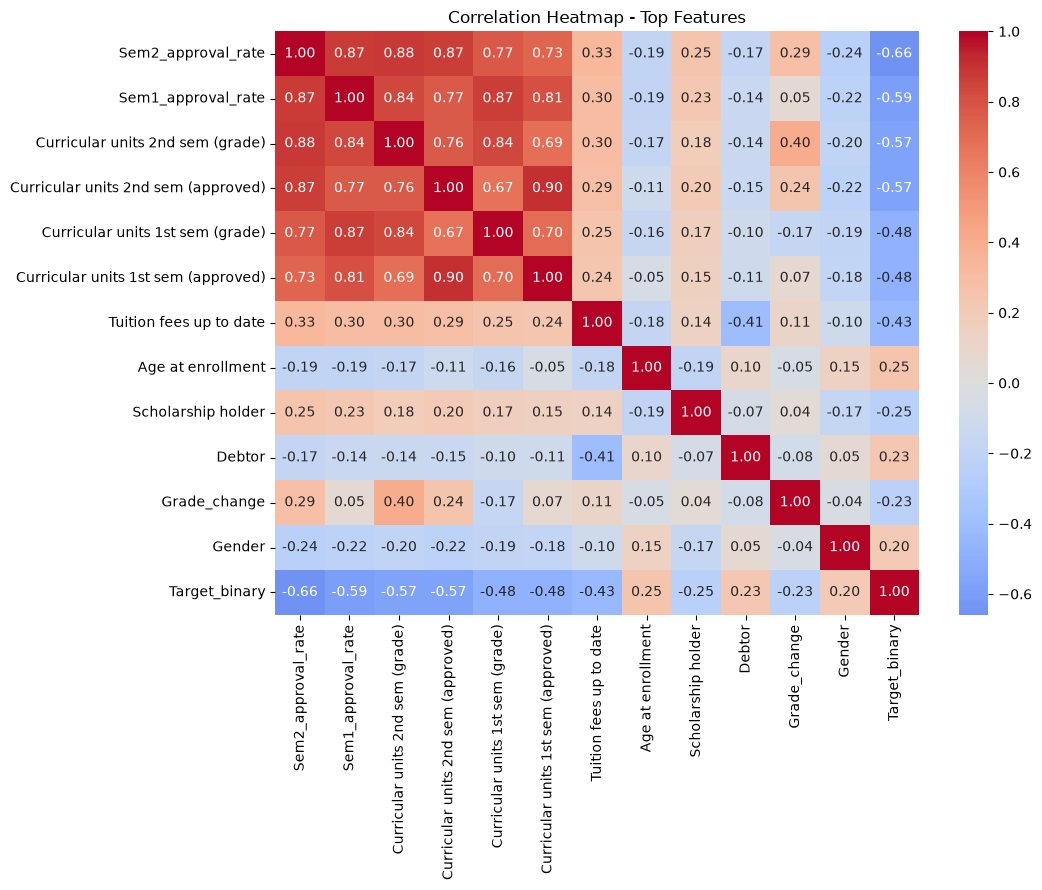

In [12]:
numeric_df = df_kr.select_dtypes(include=["number"])

corr_with_target = (
    numeric_df.corr()["Target_binary"]
    .drop("Target_binary")
    .sort_values(key=abs, ascending=False)
)

print("Target_binary와 절대 상관계수가 큰 변수 Top 15")
display(corr_with_target.head(15).to_frame("correlation"))

top_corr_features = corr_with_target.head(12).index.tolist() + ["Target_binary"]

plt.figure(figsize=(11, 9))
sns.heatmap(
    numeric_df[top_corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap - Top Features")
plt.tight_layout()
plt.show()


### 상관관계 해석 주의
- 상관계수가 크다고 해서 **원인**이라는 뜻은 아닙니다.
- 이수율처럼 기존 학기 변수로부터 계산된 파생변수는 원 변수들과 높은 상관을 가질 수 있습니다.
- 모델링 단계에서는 다중공선성, 중복 정보, 데이터 누수 가능성을 별도로 검토해야 합니다.


## 11-9. 중도이탈률 차이가 큰 변수 자동 요약

In [13]:
# 0/1 변수에 대해서 두 집단 간 중도이탈률 차이를 자동 계산
candidate_binary = []

for col in df_kr.columns:
    if col == "Target_binary":
        continue

    unique_values = set(df_kr[col].dropna().unique())

    if unique_values.issubset({0, 1}) and len(unique_values) == 2:
        candidate_binary.append(col)

binary_gap_rows = []

for col in candidate_binary:
    rates = df_kr.groupby(col)["Target_binary"].mean()

    if 0 in rates.index and 1 in rates.index:
        binary_gap_rows.append({
            "feature": col,
            "dropout_rate_when_0": rates.loc[0],
            "dropout_rate_when_1": rates.loc[1],
            "absolute_gap": abs(rates.loc[1] - rates.loc[0])
        })

binary_gap = (
    pd.DataFrame(binary_gap_rows)
    .sort_values("absolute_gap", ascending=False)
)

display(
    binary_gap.head(15)
    .style.format({
        "dropout_rate_when_0": "{:.1%}",
        "dropout_rate_when_1": "{:.1%}",
        "absolute_gap": "{:.1%}",
    })
)


,feature,dropout_rate_when_0,dropout_rate_when_1,absolute_gap
4,Tuition fees up to date,86.6%,24.7%,61.8%
3,Debtor,28.3%,62.0%,33.7%
6,Scholarship holder,38.7%,12.2%,26.5%
5,Gender,25.1%,45.1%,19.9%
0,Daytime/evening attendance,42.9%,30.8%,12.1%
1,Displaced,37.6%,27.6%,10.1%
7,International,32.2%,29.1%,3.1%
2,Educational special needs,32.1%,33.3%,1.2%


# 12. EDA 핵심 결론

이번 EDA에서 가장 먼저 확인해야 할 메시지는 다음과 같습니다.

1. **Target은 약 32%가 Dropout**으로, 평가 지표를 Accuracy 하나로 제한하면 안 됩니다.
2. **등록금 납부, 채무, 장학금** 등 경제 관련 변수에서 큰 중도이탈률 차이가 관찰됩니다.
3. **1·2학기 이수율과 성적**은 중도이탈 집단과 비중도이탈 집단 사이의 차이가 큽니다.
4. 특히 중도이탈 집단에서 **2학기 학업성과가 더 악화되는 패턴**이 보입니다.
5. 따라서 모델링에서는 단순 인구통계 정보뿐 아니라  
   `Sem1_approval_rate`, `Sem2_approval_rate`, `Grade_change`, `Approval_rate_change` 같은  
   **학업 진행 과정 변수**를 중요 후보로 검토할 가치가 있습니다.
6. 다만 EDA에서 발견한 관계는 **인과관계가 아니라 연관성**입니다.

### 모델링 단계에서 이어서 할 일
- Train / Validation / Test 분리
- 범주형 변수 One-Hot Encoding
- 필요 시 Scaling
- Logistic Regression / RandomForest / XGBoost / LightGBM 비교
- Recall, F1, ROC-AUC, PR-AUC 중심 평가
- Feature Importance / SHAP 등을 통한 주요 위험요인 해석
